In [1]:
import math
import os
import scipy
from scipy.optimize import lsq_linear
import numpy as np
from scipy.linalg import toeplitz
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal, halfnorm
import random
from scipy.io import loadmat
import random
import pickle
import sys
from sklearn.linear_model import RidgeCV
sys.path.append(r"c:\Users\katie\OneDrive\Documents\GitHub\trial")
import PCA_Regress as pcar
from brokenaxes import brokenaxes
from matplotlib.gridspec import GridSpec

In [2]:
base_path =r"c:\Users\katie\OneDrive\Desktop\Thesis"
with open(base_path+'\J_neu.pkl', "rb") as input_file:
    J_pickle = pickle.load(input_file)
del input_file

file_path = os.path.join(base_path, 'N_neu.pkl')
with open(file_path, "rb") as input_file:
    N_pickle = pickle.load(input_file)
del input_file

base_path =r"c:\Users\katie\OneDrive\Desktop\Thesis"
with open(base_path+'\J_mus.pkl', "rb") as input_file:
    J_pickle_m = pickle.load(input_file)
del input_file

ile_path = os.path.join(base_path, 'N_mus.pkl')
with open(ile_path, "rb") as input_file:
    N_pickle_m = pickle.load(input_file)
del input_file

# base_path = "/Users/kb6113/Desktop/Thesis"
# with open(base_path+'/J_neu.pkl', "rb") as input_file:
#     J_pickle = pickle.load(input_file)
# del input_file

# with open(base_path+'/J_mus.pkl', "rb") as input_file:
#     J_pickle_m = pickle.load(input_file)
# del input_file

J_all_tensor = J_pickle['J_all']['interpPSTH']
J_M1_tensor = J_pickle['J_M1']['interpPSTH']
J_PMd_tensor = J_pickle['J_PMd']['interpPSTH']
J_idx = np.r_[0:18, 36:45]
J_ntm_tensor = J_all_tensor[J_idx, :, :]
J_mus_tensor = J_pickle_m['interpPSTH']


N_all_tensor = N_pickle['N_all']['interpPSTH']
N_M1_tensor = N_pickle['N_M1']['interpPSTH']
N_PMd_tensor = N_pickle['N_PMd']['interpPSTH']
N_mus_tensor = N_pickle_m['interpPSTH']

<>:2: SyntaxWarning: invalid escape sequence '\J'
<>:12: SyntaxWarning: invalid escape sequence '\J'
<>:2: SyntaxWarning: invalid escape sequence '\J'
<>:12: SyntaxWarning: invalid escape sequence '\J'
C:\Users\katie\AppData\Local\Temp\ipykernel_22864\3800015342.py:2: SyntaxWarning: invalid escape sequence '\J'
  with open(base_path+'\J_neu.pkl', "rb") as input_file:
C:\Users\katie\AppData\Local\Temp\ipykernel_22864\3800015342.py:12: SyntaxWarning: invalid escape sequence '\J'
  with open(base_path+'\J_mus.pkl', "rb") as input_file:


[18 12  1 19  3 20  7 15 13 25 24 16 21 23 17  9 26 22 11  2  8  4]
>>> best_lam returning: 11.937766417144381


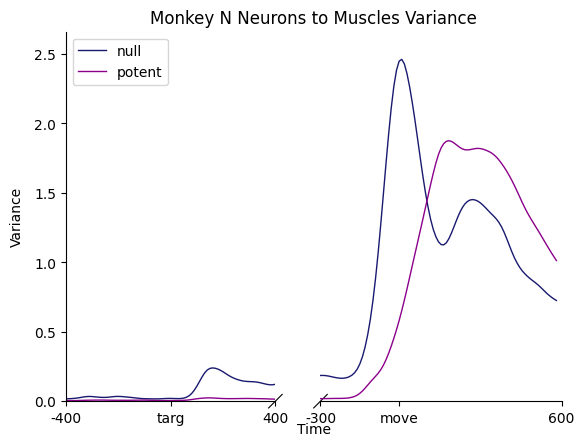

In [33]:
pcar.sup_tuning(N_all_tensor, N_mus_tensor)

[22 19  4 11 24 25 13 10 15 16 14  2  7  3  6 18 17 12 21 20  0 23]
>>> best_lam returning: 2.424462017082331


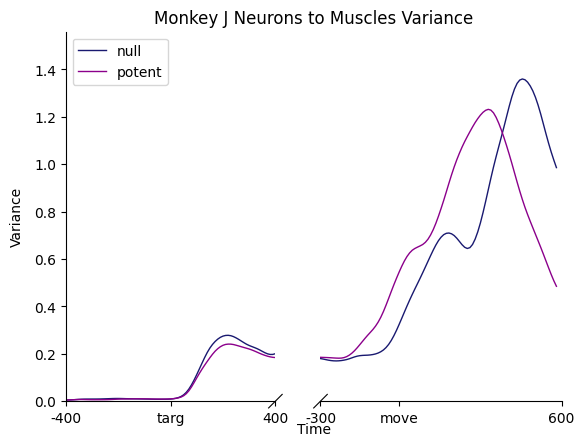

In [32]:
pcar.sup_tuning(J_ntm_tensor, J_mus_tensor)

# best lam = 100

[15 11  9  8 12  5  0 24  7 17 22 25  1  2 26  3 16 13 14  6 18 20]
>>> best_lam returning: 58.780160722749116


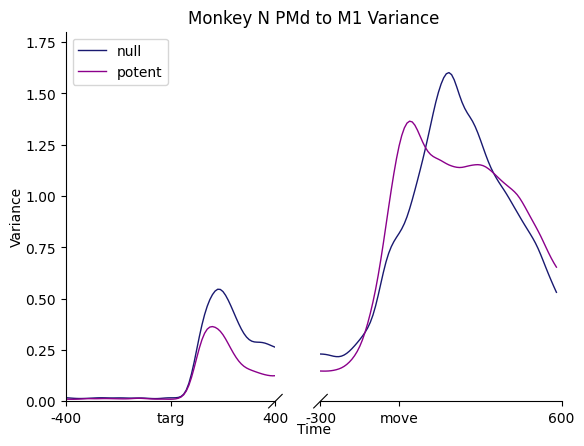

In [21]:
pcar.sup_tuning(N_PMd_tensor, N_M1_tensor, dims = 14) 

# best lam = 58.780160722749116

[ 99  98  58  83  50  95  81  82  19  34  36  97  17  43  94  63  10  66
  74 102  13  59  35  88  37  42  29   1  68  12  40  89   4  18   3  30
  92  71   9  54  45  60  11   7  75  16   8  48  51  61   6  91  80  33
   2  14  86  27  24  55 101  53  15  76  23  22  69 103  25  62  73  67
  87  85  31  78  70  28  52   0  79  57  38  49  90  72  56]
>>> best_lam returning: 11.937766417144381


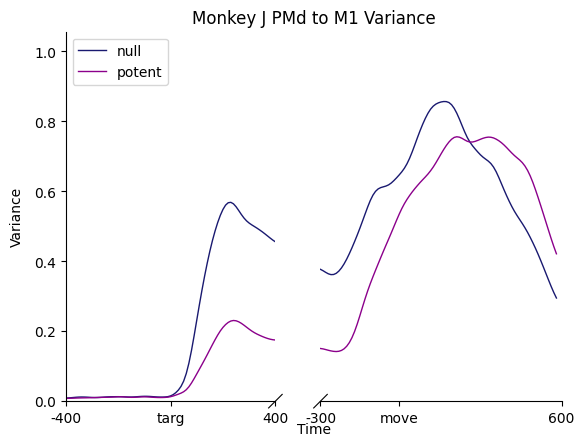

In [15]:
pcar.sup_tuning(J_PMd_tensor, J_M1_tensor, dims = 14)

[ 84   9  85  54  51   3  18   2  74  14  55  66  80  70  36  41  52  99
  73   1  92  64  86  27  56  44  35  88  47  30  49  97  46  82  83  72
   4  58  59  29  57  12 103  17  76   8  60  40  94  24 100  43  34  26
   6  31  91  95  78  42  20  10  11  89  93  53 101  81  38 106   0 104
  87  67 107  25  98  15   7  45  28  96  50  77  71  79  75]
>>> best_lam returning: 20.30917620904739


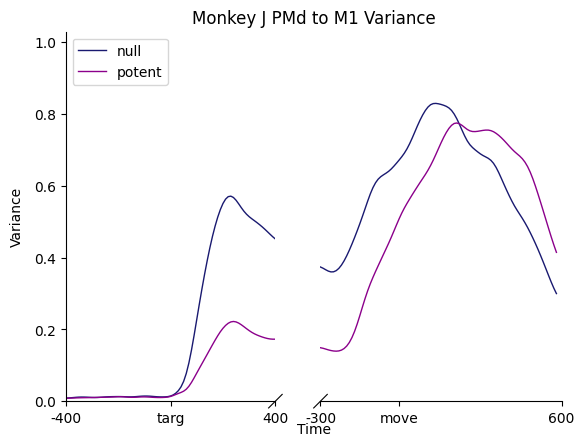

In [16]:
pcar.sup_tuning(J_PMd_tensor, J_M1_tensor, dims = 14)

[19 20 11 13 10  8 18 22 26  1  9 23 21  4  7  5 25  2 24  0 12 16]
>>> best_lam returning: 20.30917620904739


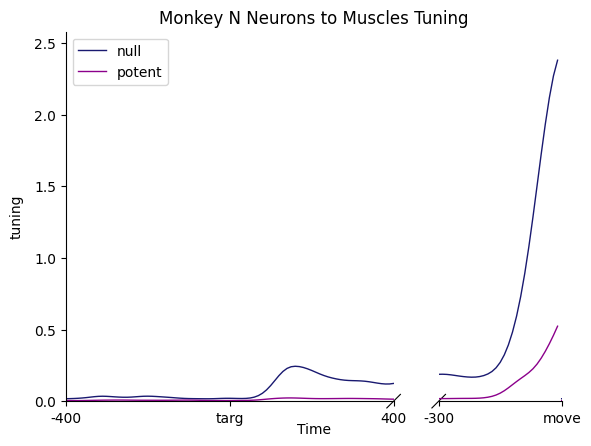

In [17]:
pcar.sup_tuning(N_all_tensor, N_mus_tensor, fig_4D = True)

In [9]:
def fig4_d (tensor_N, tensor_M, dims):

    
    # retrieving dataset specifications 
    J, PMd = pcar.ident(tensor_N)

    # getting weights matrix for potent and null space 
    cond, _, fin_time = tensor_N.shape
    regress_N, _, _ = pcar.time_shift(tensor_N, tensor_M, fig4 = True)
    N_tilde, _, _ = pcar.run_PCA(regress_N, dims)
    W_potent, W_null = pcar.tuning_setup(tensor_N, tensor_M, dims, time = True)
    
    # projecting the neural activity of 400ms before and after target and 300ms before and 800ms after move starts onto the potent and null space of the weights matrix
    N_potent = N_tilde @ W_potent
    N_null = N_tilde @ W_null

    # reshaping into a tensor 
    pot_tensor = pcar.shape_tensor(N_potent, cond)
    null_tensor = pcar.shape_tensor(N_null, cond)
    _, _, time = pot_tensor.shape

    # initializing array for holding the variance 
    V_pot = np.zeros(time)
    V_null = np.zeros(time)
    _, _, time = null_tensor.shape

    ratio = np.zeros(time)

    for t in range(time):

        Xn = null_tensor[:,:,t]
        Xp = pot_tensor[:,:,t]

        # subtract condition mean
        Xn -= Xn.mean(axis=0, keepdims=True)
        Xp -= Xp.mean(axis=0, keepdims=True)

        V_null = np.sum(Xn**2)
        V_pot  = np.sum(Xp**2)

        ratio[t] = (1/gamma) * (V_null / V_pot)